# Airbnb Listing Analysis: NYC's Accommodation Landscape
---

### Opening Question
**How does room type, location, and host behaviour influence pricing and guest satisfaction across New York City's Airbnb market? Are expensive listings genuinely more popular, or is there a sweet spot that maximises both revenue and review activity?**

### Objective
To uncover patterns in NYC's Airbnb ecosystem by analysing the relationships between listing characteristics (room type, neighbourhood, price), host activity, and guest engagement metrics. Rather than making assumptions about what makes a "successful" listing, I'll examine actual correlations between pricing, availability, minimum stay requirements, and review activity to identify the factors that genuinely drive guest interaction.

### Dataset Overview
- **Sample Size**: 48,895 unique Airbnb listings in New York City
- **Variables**: id, name, host_id, host_name, neighbourhood_group, neighbourhood, latitude, longitude, room_type, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count, availability_365
- **Analysis Approach**: Exploratory Data Analysis [EDA], focusing on spatial distribution, pricing strategies, host patterns, and guest engagement metrics through visualisations and statistical summaries.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [105]:
# colour scheme for consistency
primary = "#d59de3"
secondary = "#345882"
success = "#2ca02c"
danger = "#d62728"
warning = "#ff9896"

# gradient for distributions
gradient = ["#d59de3", "#b291d6", "#8c84c7", "#6477b6", "#48689d", "#345882"]

### 1. What does the dataset look like at first glance?

Let me start with the basics. Load the data, take a look at structure, size, and get an initial sense of what we're working with. Spoiler: there are a lot of listings.

In [106]:
# load the dataset
path = "airbnb.csv"
df = pd.read_csv(path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:\n{df.dtypes}")

Dataset shape: (48895, 16)

Column names and types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [107]:
# first few rows
print("Sample listings:")
df.head()

Sample listings:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [108]:
# basic statistics
print("\nNumeric summary:")
df.describe()


Numeric summary:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [109]:
# data quality check
print("\nMissing values:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / (len(df)-1)) * 100
missing_df = pd.DataFrame({"Missing": missing_data, "Percent": missing_percent})
print(missing_df[missing_df["Missing"] > 0])

print(f"\nDuplicate listings: {df.duplicated().sum()}")


Missing values:
                   Missing    Percent
name                    16   0.032724
host_name               21   0.042950
last_review          10052  20.558760
reviews_per_month    10052  20.558760

Duplicate listings: 0


### 2. Understanding the Room Types and Geographic Distribution

First question: what kinds of accommodation are people renting? Are we mostly seeing entire apartments or private rooms? And where is everything located?

Room types available:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

Percentages:
room_type
Entire home/apt    51.97
Private room       45.66
Shared room         2.37
Name: count, dtype: float64


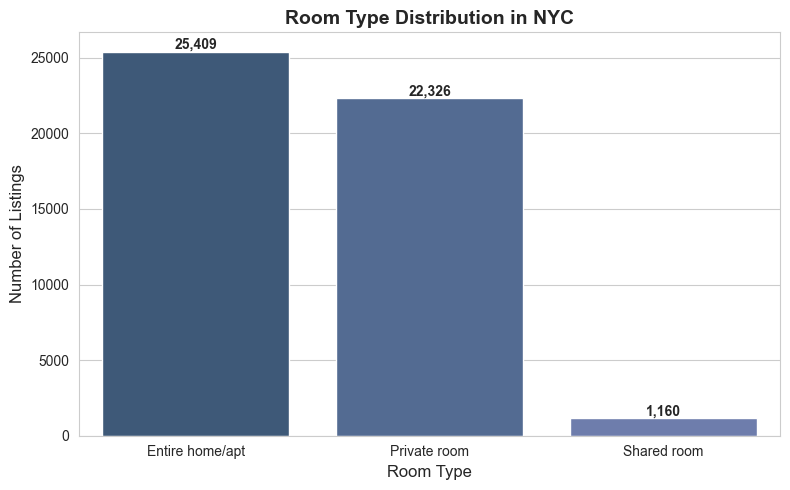

In [110]:
# room type distribution
room_counts = df["room_type"].value_counts()
print("Room types available:")
print(room_counts)
print(f"\nPercentages:")
print((room_counts / len(df) * 100).round(2))

# bar chart
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=room_counts.index, y=room_counts.values, palette=gradient[::-1], ax=ax)
ax.set_title('Room Type Distribution in NYC', fontsize=14, fontweight='bold')
ax.set_xlabel('Room Type', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(room_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


Listings by neighbourhood group:
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

Percentages:
neighbourhood_group
Manhattan        44.30
Brooklyn         41.12
Queens           11.59
Bronx             2.23
Staten Island     0.76
Name: count, dtype: float64


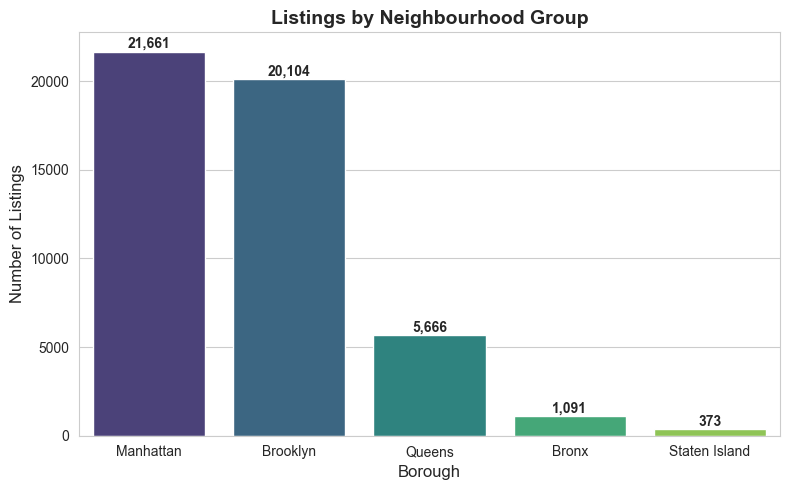

In [111]:
# geographic breakdown
print("\nListings by neighbourhood group:")
neighbourhood_group = df["neighbourhood_group"].value_counts()
print(neighbourhood_group)
print(f"\nPercentages:")
print((neighbourhood_group / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=neighbourhood_group.index, y=neighbourhood_group.values, palette='viridis', ax=ax)
ax.set_title('Listings by Neighbourhood Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Borough', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(neighbourhood_group.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


Room type distribution by neighbourhood:
room_type            Entire home/apt  Private room  Shared room    All
neighbourhood_group                                                   
Bronx                            379           652           60   1091
Brooklyn                        9559         10132          413  20104
Manhattan                      13199          7982          480  21661
Queens                          2096          3372          198   5666
Staten Island                    176           188            9    373
All                            25409         22326         1160  48895

Percentage distribution of room types by neighbourhood:
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          34.74         59.76         5.50
Brooklyn                       47.55         50.40         2.05
Manhattan                      60.93         36.85         2.22
Queens       

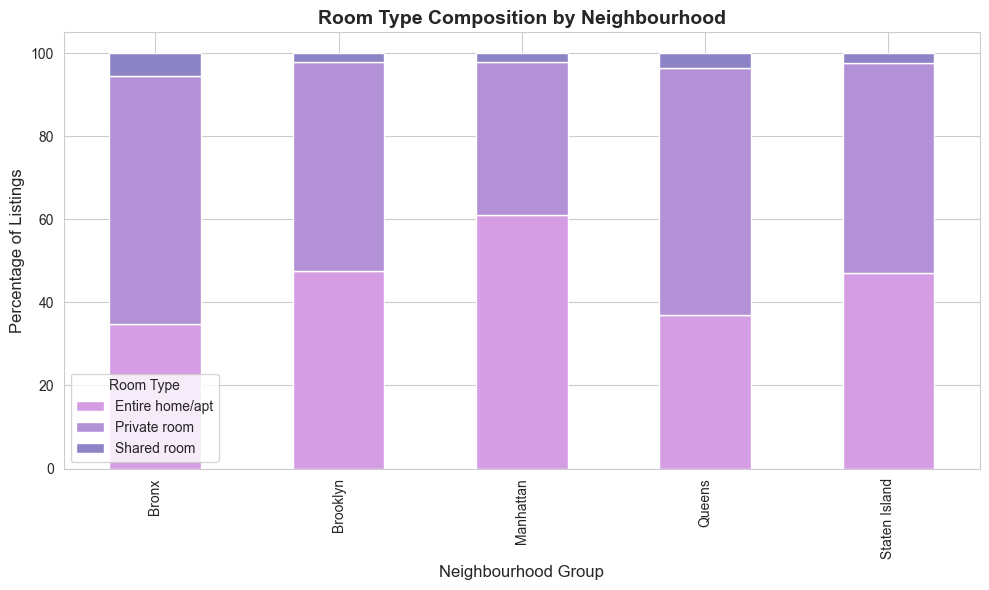

In [112]:
# cross-tabulation: room type vs neighbourhood
crosstab = pd.crosstab(df["neighbourhood_group"], df["room_type"], margins=True)
print("\nRoom type distribution by neighbourhood:")
print(crosstab)

crosstab_pct = pd.crosstab(df["neighbourhood_group"], df["room_type"], normalize="index") * 100
print("\nPercentage distribution of room types by neighbourhood:")
print(crosstab_pct.round(2))

# stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
crosstab_pct.plot(kind='bar', stacked=True, ax=ax, color=gradient)
ax.set_title('Room Type Composition by Neighbourhood', fontsize=14, fontweight='bold')
ax.set_xlabel('Neighbourhood Group', fontsize=12)
ax.set_ylabel('Percentage of Listings', fontsize=12)
ax.legend(title='Room Type')
plt.tight_layout()
plt.show()

### 3. Pricing Analysis: What Are People Charging?

Price is where things get interesting. What's the distribution like? Are there outliers? Do prices vary wildly by neighbourhood and room type?

Price statistics (in USD for per night):
Mean: $152.72
Median: $106.00
Min: $0.00
Max: $10000.00
Std Dev: $240.15


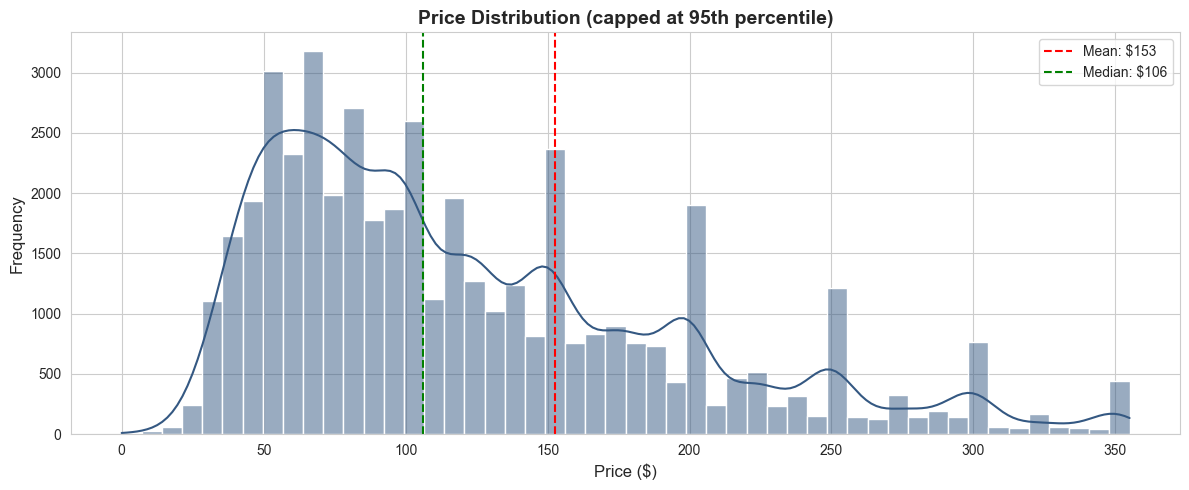

In [113]:
# price statistics
print("Price statistics (in USD for per night):")
print(f"Mean: ${df['price'].mean():.2f}")
print(f"Median: ${df['price'].median():.2f}")
print(f"Min: ${df['price'].min():.2f}")
print(f"Max: ${df['price'].max():.2f}")
print(f"Std Dev: ${df['price'].std():.2f}")

# histogram (capped at 95th percentile for visibility)
cap = df['price'].quantile(0.95)
filtered_price = df[df['price'] <= cap]['price']
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(filtered_price, bins=50, kde=True, color=secondary, ax=ax)
ax.set_title('Price Distribution (capped at 95th percentile)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: ${df['price'].mean():.0f}")
ax.axvline(df['price'].median(), color='green', linestyle='--', label=f"Median: ${df['price'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()


Price by room type:
                 Count    Mean  Median  Std Dev  Min    Max
room_type                                                  
Entire home/apt  25409  211.79   160.0   284.04    0  10000
Private room     22326   89.78    70.0   160.21    0  10000
Shared room       1160   70.13    45.0   101.73    0   1800


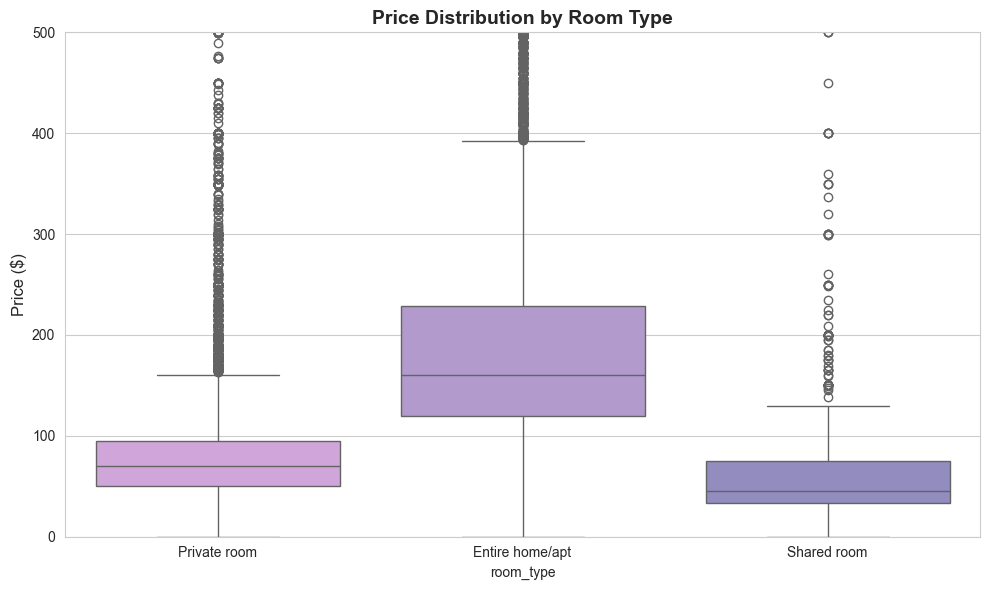

In [114]:
# price by room type
print("\nPrice by room type:")
room_price = df.groupby("room_type")["price"].agg(["count", "mean", "median", "std", "min", "max"])
room_price.columns = ["Count", "Mean", "Median", "Std Dev", "Min", "Max"]
print(room_price.round(2))

# boxplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='room_type', y='price', palette=gradient, ax=ax)
ax.set_title('Price Distribution by Room Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_ylim(0, 500)  # zoom in for readability
plt.tight_layout()
plt.show()


Price by neighbourhood group:
                     Count    Mean  Median  Std Dev  Min    Max
neighbourhood_group                                            
Manhattan            21661  196.88   150.0   291.38    0  10000
Brooklyn             20104  124.38    90.0   186.87    0  10000
Staten Island          373  114.81    75.0   277.62   13   5000
Queens                5666   99.52    75.0   167.10   10  10000
Bronx                 1091   87.50    65.0   106.71    0   2500


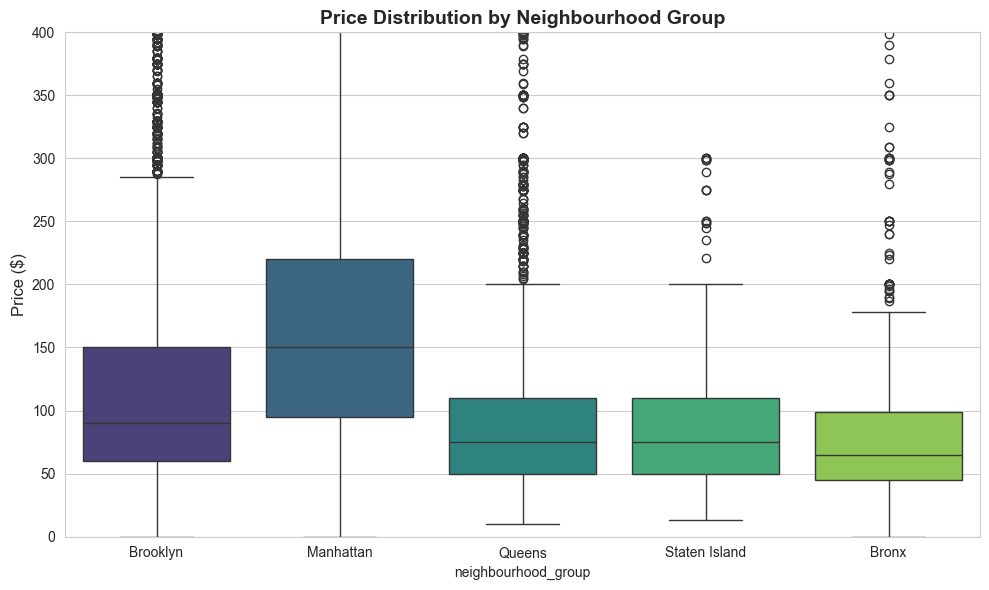

In [115]:
# price by neighbourhood
print("\nPrice by neighbourhood group:")
neighbourhood_price = df.groupby("neighbourhood_group")["price"].agg(["count", "mean", "median", "std", "min", "max"])
neighbourhood_price.columns = ["Count", "Mean", "Median", "Std Dev", "Min", "Max"]
print(neighbourhood_price.round(2).sort_values("Mean", ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='neighbourhood_group', y='price', palette='viridis', ax=ax)
ax.set_title('Price Distribution by Neighbourhood Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_ylim(0, 400)
plt.tight_layout()
plt.show()

In [116]:
# detect outliers using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR # 69 - (1.5 * 106)
upper_bound = Q3 + 1.5 * IQR # 175 + (1.5 * 106)

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"Price outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Outlier range: ${lower_bound:.2f} to ${upper_bound:.2f}")
print(f"\nActual extreme values: ${df['price'].min():.2f} to ${df['price'].max():.2f}")

69.0
175.0
Price outliers detected: 2972 (6.08%)
Outlier range: $-90.00 to $334.00

Actual extreme values: $0.00 to $10000.00


### 4. Minimum Stay Requirements: How Picky Are Hosts?

Minimum night requirements can make or break a booking for tourists. What's the landscape? Who's requiring 30-day minimums versus those welcoming short stays?

Minimum nights required:
Mean: 7.03 nights
Median: 3.00 nights
Min: 1 nights
Max: 1250 nights


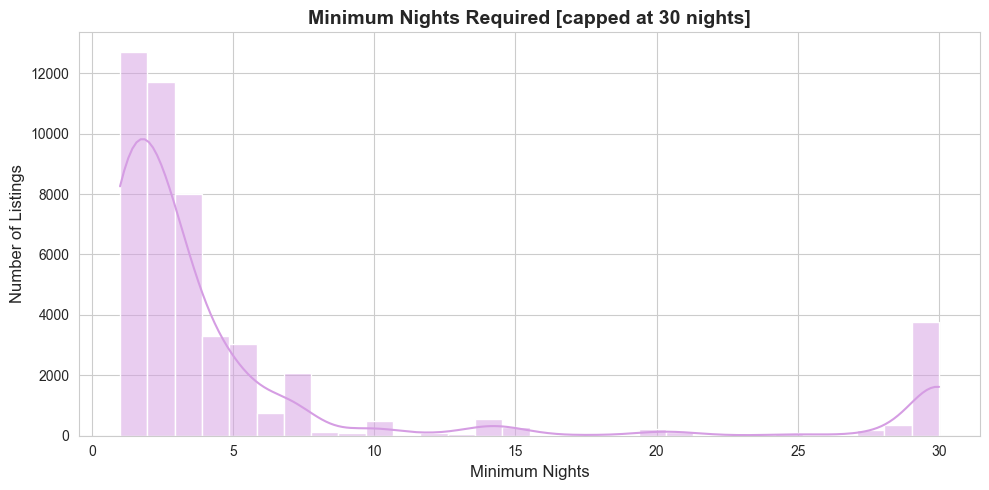


Minimum stay categories:
min_stay_category
1-7 days     28842
Nightly      12720
8-30 days     6586
30+ days       747
Name: count, dtype: int64

Percentages:
min_stay_category
1-7 days     58.99
Nightly      26.01
8-30 days    13.47
30+ days      1.53
Name: count, dtype: float64


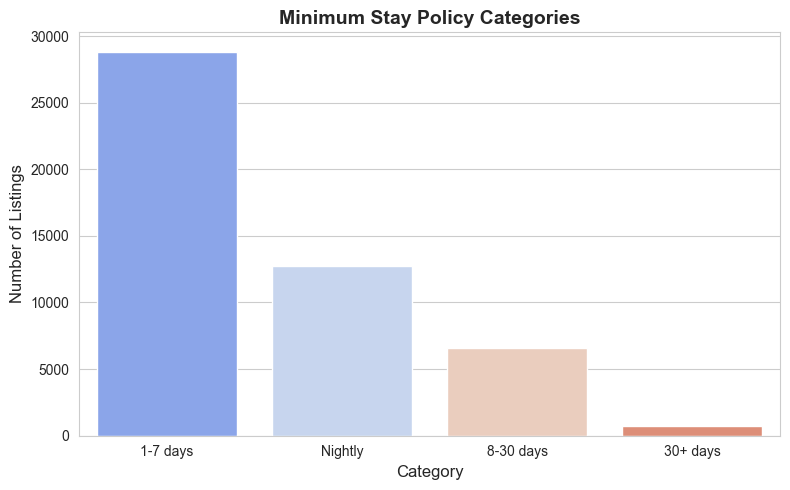

In [117]:
# minimum nights statistics
print("Minimum nights required:")
print(f"Mean: {df['minimum_nights'].mean():.2f} nights")
print(f"Median: {df['minimum_nights'].median():.2f} nights")
print(f"Min: {df['minimum_nights'].min()} nights")
print(f"Max: {df['minimum_nights'].max()} nights")

# histogram (capped at 30 days for readability)
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[df['minimum_nights'] <= 30]['minimum_nights'], bins=30, color=primary, kde=True, ax=ax)
ax.set_title('Minimum Nights Required [capped at 30 nights]', fontsize=14, fontweight='bold')
ax.set_xlabel('Minimum Nights', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

# categorise minimum stay policies
def categorise_min_stay(nights):
    if nights == 1:
        return "Nightly"
    elif nights <= 7:
        return "1-7 days"
    elif nights <= 30:
        return "8-30 days"
    else:
        return "30+ days"

df["min_stay_category"] = df["minimum_nights"].apply(categorise_min_stay)
print("\nMinimum stay categories:")
stay_dist = df["min_stay_category"].value_counts()
print(stay_dist)
print(f"\nPercentages:")
print((stay_dist / len(df) * 100).round(2))

# bar chart
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=stay_dist.index, y=stay_dist.values, palette='coolwarm', ax=ax)
ax.set_title('Minimum Stay Policy Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

### 5. Review Activity: The Engagement Metric

How popular are these listings actually? Review count and frequency tell us which listings guests genuinely book and which ones are just sitting there looking pretty.

Review activity overview:
Total listings with at least one review: 38843 (79.44%)
Listings with zero reviews: 10052 (20.56%)

For listings with reviews (n=38843):
Mean reviews: 29.30
Median reviews: 9.00
Max reviews: 629


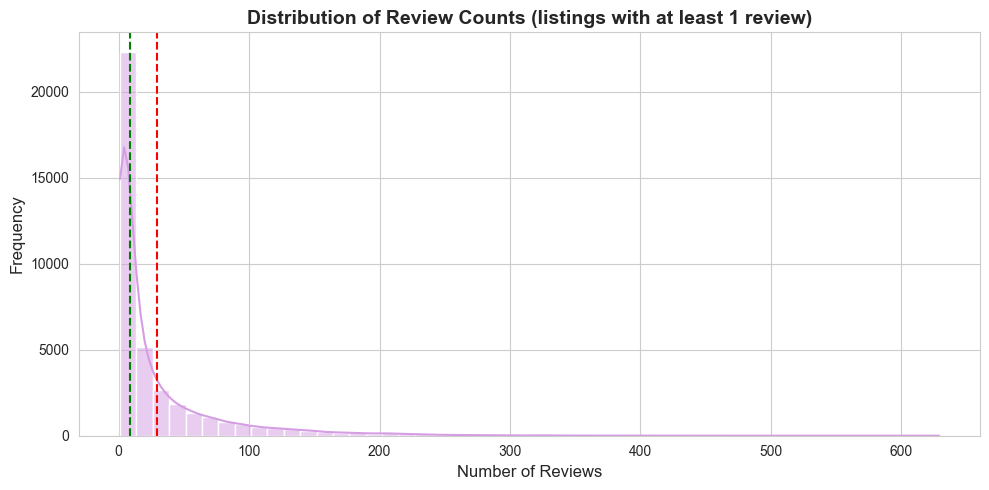

In [118]:
# review statistics
print("Review activity overview:")
print(f"Total listings with at least one review: {(df['number_of_reviews'] > 0).sum()} ({(df['number_of_reviews'] > 0).sum()/len(df)*100:.2f}%)")
print(f"Listings with zero reviews: {(df['number_of_reviews'] == 0).sum()} ({(df['number_of_reviews'] == 0).sum()/len(df)*100:.2f}%)")

# for listings with reviews
reviewed = df[df["number_of_reviews"] > 0]
print(f"\nFor listings with reviews (n={len(reviewed)}):")
print(f"Mean reviews: {reviewed['number_of_reviews'].mean():.2f}")
print(f"Median reviews: {reviewed['number_of_reviews'].median():.2f}")
print(f"Max reviews: {reviewed['number_of_reviews'].max()}")

# histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(reviewed['number_of_reviews'], bins=50, color=primary, kde=True, ax=ax)
ax.set_title('Distribution of Review Counts (listings with at least 1 review)', fontsize=14, fontweight='bold')
ax.axvline(reviewed['number_of_reviews'].mean(), color='red', linestyle='--', label=f"Mean: {reviewed['number_of_reviews'].mean():.0f}")
ax.axvline(reviewed['number_of_reviews'].median(), color='green', linestyle='--', label=f"Median: {reviewed['number_of_reviews'].median():.0f}")
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


Reviews per month (for active listings):
Mean: 1.37 reviews/month
Median: 0.72 reviews/month
Max: 58.50 reviews/month


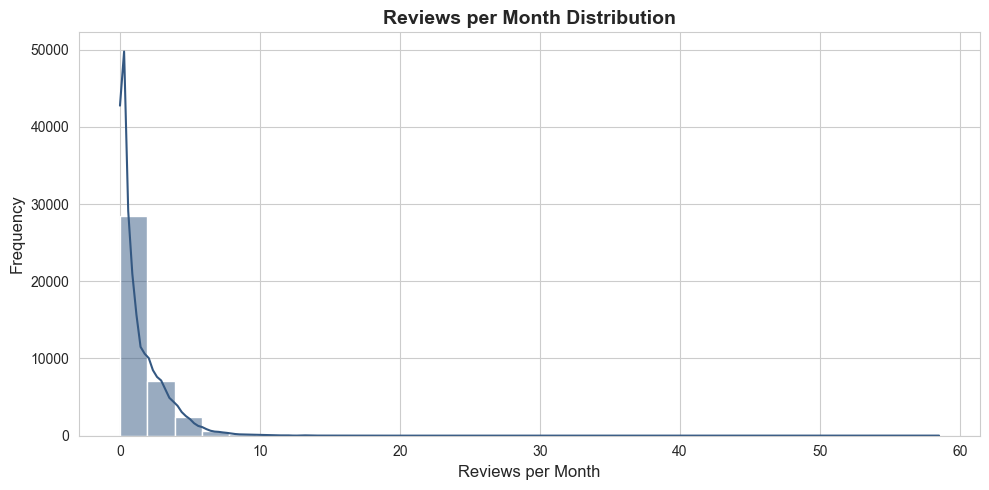

In [119]:
# reviews per month (only for listings with data)
rpm_data = df[df["reviews_per_month"].notna()]
print(f"\nReviews per month (for active listings):")
print(f"Mean: {rpm_data['reviews_per_month'].mean():.2f} reviews/month")
print(f"Median: {rpm_data['reviews_per_month'].median():.2f} reviews/month")
print(f"Max: {rpm_data['reviews_per_month'].max():.2f} reviews/month")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(rpm_data['reviews_per_month'], bins=30, color=secondary, kde=True, ax=ax)
ax.set_title('Reviews per Month Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Reviews per Month', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


Review metrics by room type:
                number_of_reviews        reviews_per_month       
                             mean median              mean median
room_type                                                        
Entire home/apt             22.84    5.0              1.31   0.66
Private room                24.11    5.0              1.45   0.77
Shared room                 16.60    4.0              1.47   0.98


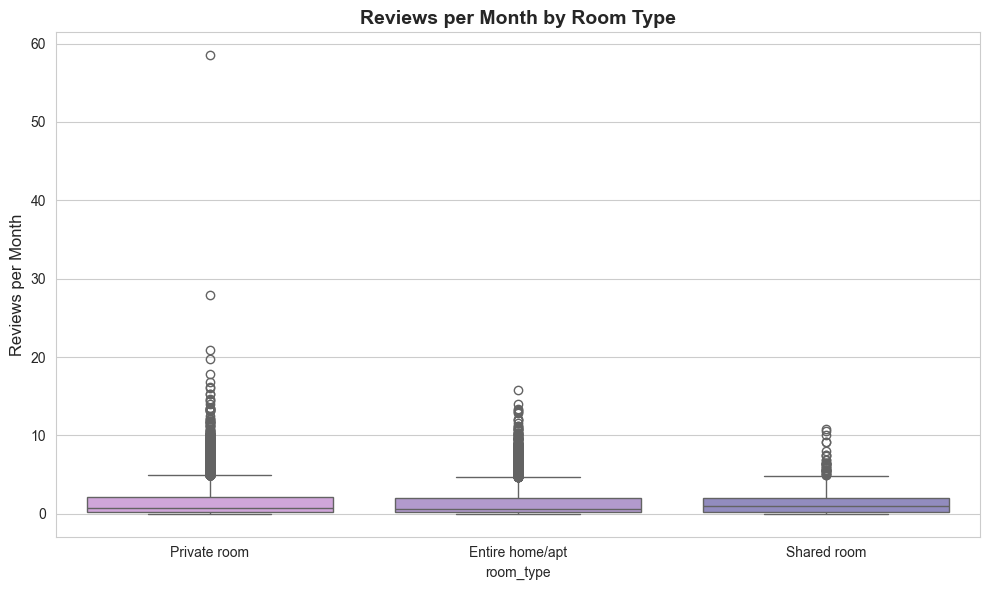

In [120]:
# reviews by room type
print("\nReview metrics by room type:")
reviews_by_type = df.groupby("room_type").agg({
    "number_of_reviews": ["mean", "median"],
    "reviews_per_month": ["mean", "median"]
}).round(2)
print(reviews_by_type)

# boxplot of reviews per month by room type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=rpm_data, x='room_type', y='reviews_per_month', palette=gradient, ax=ax)
ax.set_title('Reviews per Month by Room Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Reviews per Month', fontsize=12)
plt.tight_layout()
plt.show()

### 6. Host Concentration: Who Controls What?

Is this market dominated by professional operators or grassroots hosts? How many listings does the average host own, and are there mega-hosts running entire portfolios?

Host portfolio sizes:
count    48895.00
mean         7.14
std         32.95
min          1.00
25%          1.00
50%          1.00
75%          2.00
max        327.00
Name: calculated_host_listings_count, dtype: float64

Host categories:
host_size_category
Single listing    32303
2-5 listings      11796
10+ listings       2967
6-10 listings      1829
Name: count, dtype: int64

Percentages:
host_size_category
Single listing    66.07
2-5 listings      24.13
10+ listings       6.07
6-10 listings      3.74
Name: count, dtype: float64


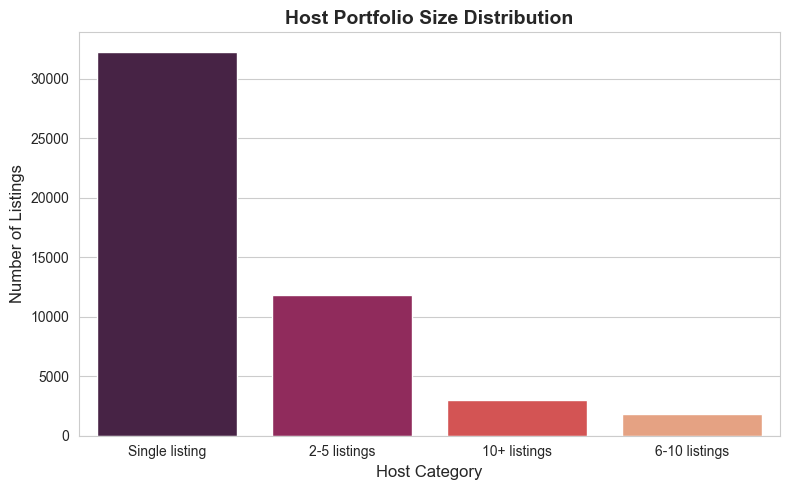

In [121]:
# host listing concentration
print("Host portfolio sizes:")
host_listings = df["calculated_host_listings_count"].describe()
print(host_listings.round(2))

# categorise hosts
def categorise_host_size(count):
    if count == 1:
        return "Single listing"
    elif count <= 5:
        return "2-5 listings"
    elif count <= 10:
        return "6-10 listings"
    else:
        return "10+ listings"

df["host_size_category"] = df["calculated_host_listings_count"].apply(categorise_host_size)
print("\nHost categories:")
host_dist = df["host_size_category"].value_counts()
print(host_dist)
print(f"\nPercentages:")
print((host_dist / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=host_dist.index, y=host_dist.values, palette='rocket', ax=ax)
ax.set_title('Host Portfolio Size Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Host Category', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()


Performance by host portfolio size:
                     price        number_of_reviews reviews_per_month
                      mean median              mean              mean
host_size_category                                                   
10+ listings        216.12  175.0              7.13              0.79
2-5 listings        124.96   85.0             35.34              1.79
6-10 listings       123.72   75.0             22.13              1.91
Single listing      158.68  119.0             20.42              1.22


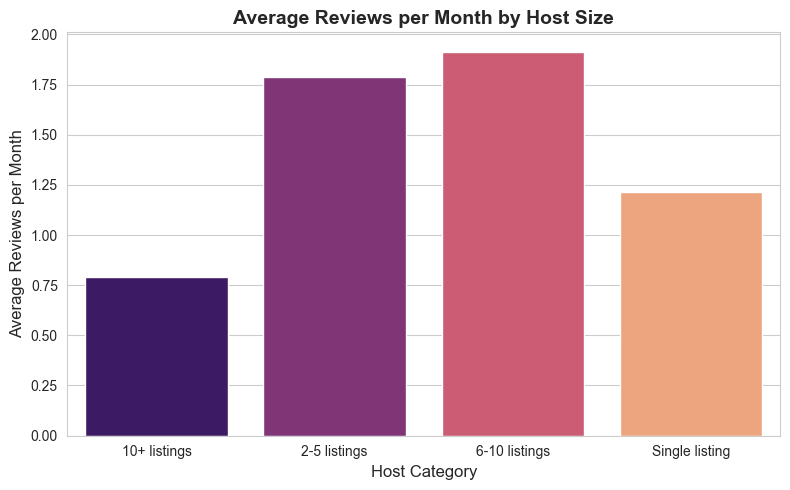

In [ ]:
# average metrics by host type
print("\nPerformance by host portfolio size:")
host_performance = df.groupby("host_size_category").agg({"price": ["mean", "median"], "number_of_reviews": "mean", "reviews_per_month": "mean"}).round(2)
print(host_performance)

# bar chart of reviews per month by host size
host_rpm = df.groupby('host_size_category')['reviews_per_month'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=host_rpm, x='host_size_category', y='reviews_per_month', palette='magma', ax=ax)
ax.set_title('Average Reviews per Month by Host Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Host Category', fontsize=12)
ax.set_ylabel('Average Reviews per Month', fontsize=12)
plt.tight_layout()
plt.show()

### 7. Availability Patterns: The Vacancy Story

How often are listings actually available? Some hosts might be blocking calendars whilst others keep slots open throughout the year.

Days available out of 365:
Mean: 112.78 days
Median: 45.00 days


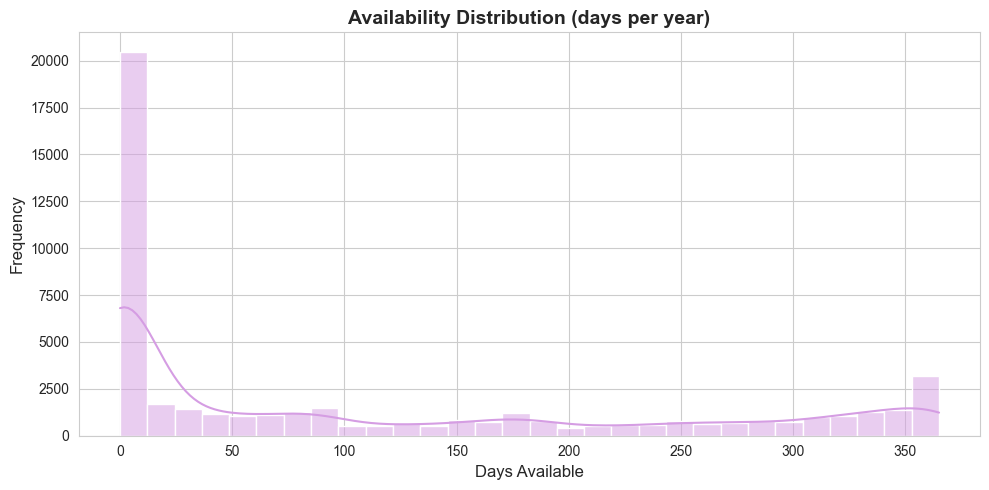


Availability categories:
availability_category
Booked year-round               17533
0-90 days [high occupancy]      11713
270-365 days [mostly empty]      9851
90-180 days [moderate]           5285
180-270 days [low occupancy]     4513
Name: count, dtype: int64

Percentages:
availability_category
Booked year-round               35.86
0-90 days [high occupancy]      23.96
270-365 days [mostly empty]     20.15
90-180 days [moderate]          10.81
180-270 days [low occupancy]     9.23
Name: count, dtype: float64


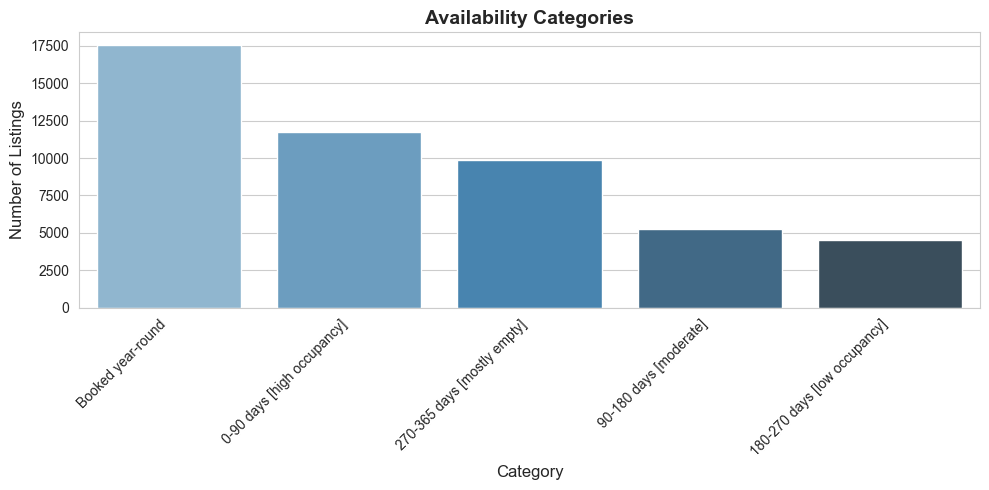

In [123]:
# availability analysis
print("Days available out of 365:")
print(f"Mean: {df['availability_365'].mean():.2f} days")
print(f"Median: {df['availability_365'].median():.2f} days")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['availability_365'], bins=30, color=primary, kde=True, ax=ax)
ax.set_title('Availability Distribution (days per year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Days Available', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# categorise by availability
def categorise_availability(days):
    if days == 0:
        return "Booked year-round"
    elif days <= 90:
        return "0-90 days [high occupancy]"
    elif days <= 180:
        return "90-180 days [moderate]"
    elif days <= 270:
        return "180-270 days [low occupancy]"
    else:
        return "270-365 days [mostly empty]"

df["availability_category"] = df["availability_365"].apply(categorise_availability)
print("\nAvailability categories:")
avail_dist = df["availability_category"].value_counts()
print(avail_dist)
print(f"\nPercentages:")
print((avail_dist / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=avail_dist.index, y=avail_dist.values, palette='Blues_d', ax=ax)
ax.set_title('Availability Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8. Correlations: What Actually Drives Success?

Now for the interesting part. What factors actually correlate with high engagement? Is expensive always unpopular? Does minimum stay affect reviews?

In [ ]:
# correlation matrix for numerical variables
numeric_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]

correlation_matrix = df[numeric_cols].corr()
print("Correlation matrix:")
correlation_matrix.round(3)

Correlation matrix:


,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000,0.043,-0.048,-0.031,0.057,0.082
minimum_nights,0.043,1.000,-0.080,-0.122,0.128,0.144
number_of_reviews,-0.048,-0.080,1.000,0.550,-0.072,0.172
reviews_per_month,-0.031,-0.122,0.550,1.000,-0.009,0.186
calculated_host_listings_count,0.057,0.128,-0.072,-0.009,1.000,0.226
availability_365,0.082,0.144,0.172,0.186,0.226,1.000


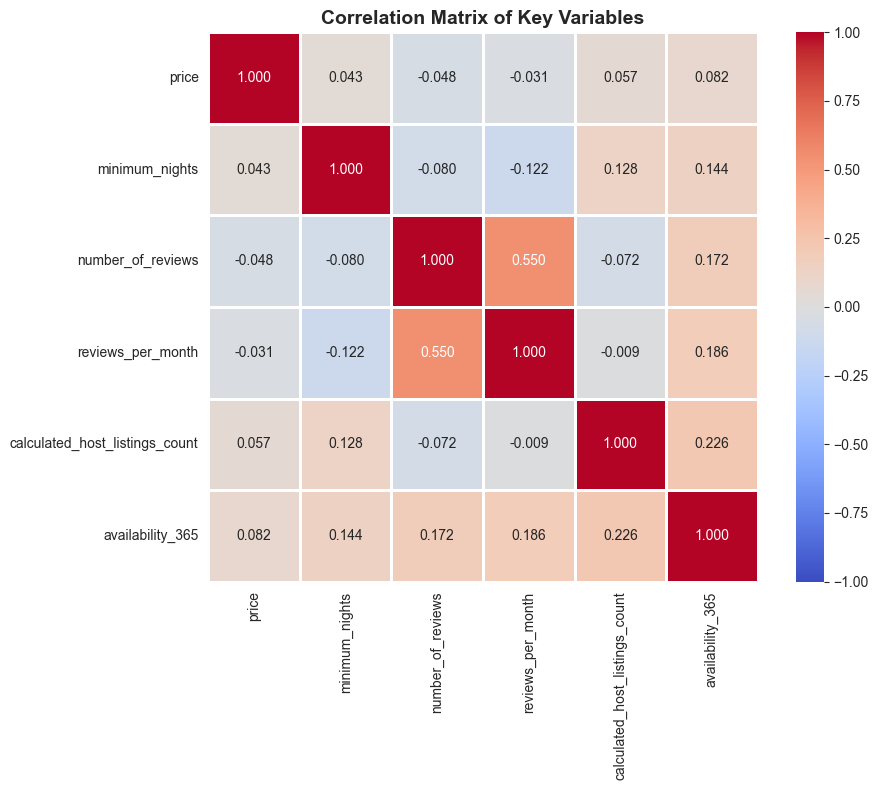

In [125]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation between price and reviews/month: -0.031


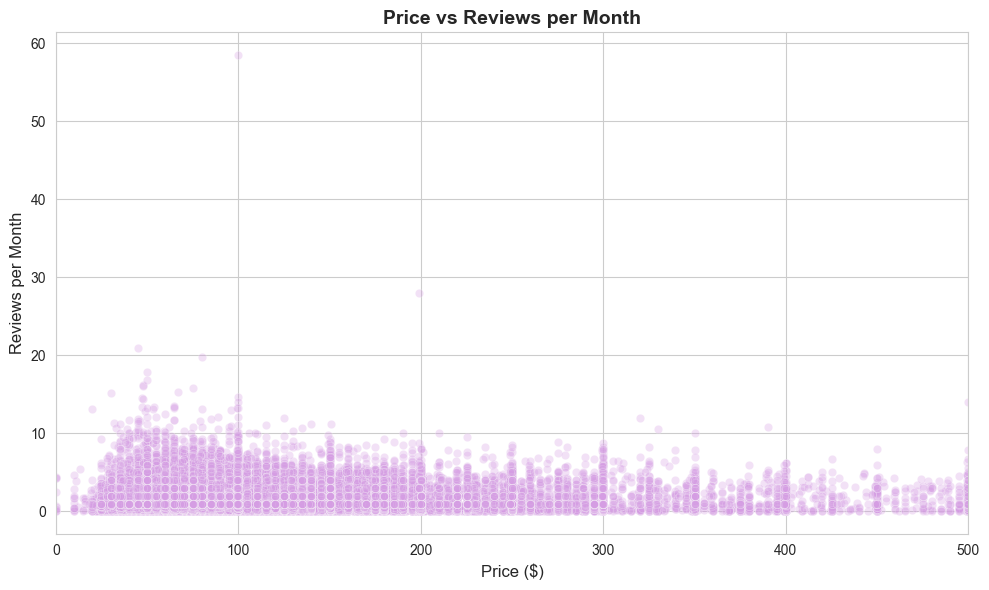

Correlation between minimum nights and review count: -0.080
Correlation between availability and review count: 0.172


In [126]:
# price vs reviews per month (scatter plot)
rpm_filtered = df[df["reviews_per_month"].notna()].copy()
correlation_price_rpm = rpm_filtered["price"].corr(rpm_filtered["reviews_per_month"])
print(f"Correlation between price and reviews/month: {correlation_price_rpm:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=rpm_filtered, x='price', y='reviews_per_month', alpha=0.3, color=primary, ax=ax)
ax.set_title('Price vs Reviews per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Price ($)', fontsize=12)
ax.set_ylabel('Reviews per Month', fontsize=12)
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()

# minimum nights vs reviews
correlation_min_nights = df["minimum_nights"].corr(df["number_of_reviews"])
print(f"Correlation between minimum nights and review count: {correlation_min_nights:.3f}")

# availability vs reviews
correlation_avail = df["availability_365"].corr(df["number_of_reviews"])
print(f"Correlation between availability and review count: {correlation_avail:.3f}")

### 9. Recency: How Fresh Are the Reviews?

Not all active listings are equally active. The last review date tells us which listings are still getting traffic versus which ones are dormant.

Latest review date: 2019-07-08 00:00:00

Days since last review (for reviewed listings):
Mean: 277 days
Median: 50 days
Max: 3024.0 days


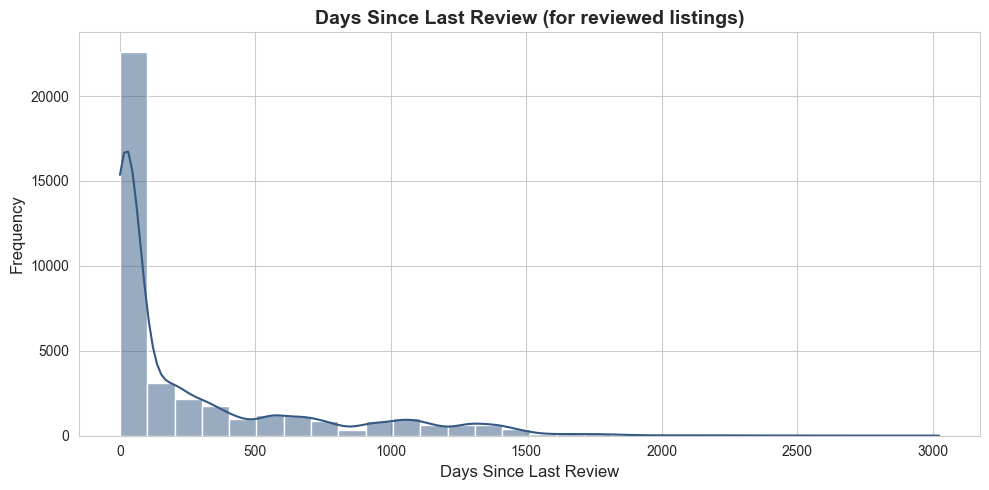

In [127]:
# convert last_review to datetime
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

# calculate days since last review
latest_date = df["last_review"].max()
df["days_since_review"] = (latest_date - df["last_review"]).dt.days

print(f"Latest review date: {latest_date}")
print(f"\nDays since last review (for reviewed listings):")
reviewed_df = df[df["last_review"].notna()]
print(f"Mean: {reviewed_df['days_since_review'].mean():.0f} days")
print(f"Median: {reviewed_df['days_since_review'].median():.0f} days")
print(f"Max: {reviewed_df['days_since_review'].max()} days")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(reviewed_df['days_since_review'], bins=30, color=secondary, kde=True, ax=ax)
ax.set_title('Days Since Last Review (for reviewed listings)', fontsize=14, fontweight='bold')
ax.set_xlabel('Days Since Last Review', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

Activity status:
recency_category
Last 30 days (very active)         15971
180+ days (stale)                  14712
Never reviewed                     10052
30-90 days (active)                 6259
90-180 days (moderately active)     1901
Name: count, dtype: int64

Percentages:
recency_category
Last 30 days (very active)         32.66
180+ days (stale)                  30.09
Never reviewed                     20.56
30-90 days (active)                12.80
90-180 days (moderately active)     3.89
Name: count, dtype: float64


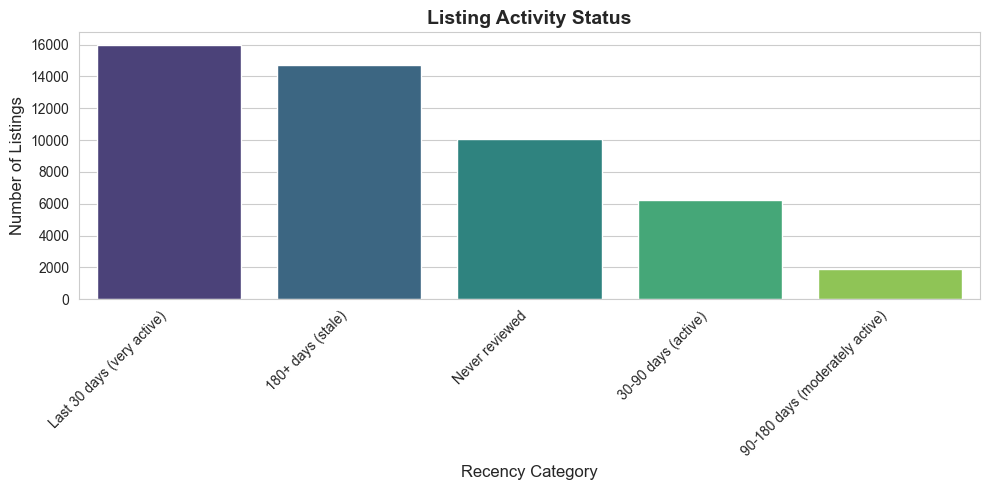

In [128]:
# categorise by recency
def categorise_recency(days):
    if pd.isna(days):
        return "Never reviewed"
    elif days <= 30:
        return "Last 30 days (very active)"
    elif days <= 90:
        return "30-90 days (active)"
    elif days <= 180:
        return "90-180 days (moderately active)"
    else:
        return "180+ days (stale)"

df["recency_category"] = df["days_since_review"].apply(categorise_recency)
print("Activity status:")
recency_dist = df["recency_category"].value_counts()
print(recency_dist)
print(f"\nPercentages:")
print((recency_dist / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=recency_dist.index, y=recency_dist.values, palette='viridis', ax=ax)
ax.set_title('Listing Activity Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Recency Category', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 10. The Sweet Spot: What Listing Profile Maximises Engagement?

Let's filter for high-engagement listings and see what they have in common. High engagement = lots of reviews + frequent recent activity.

In [129]:
# define "successful" listings
high_engagement = df[(df["number_of_reviews"] >= df["number_of_reviews"].quantile(0.75)) & (df["reviews_per_month"].notna())].copy()

print(f"High-engagement listings: {len(high_engagement)} ({len(high_engagement)/len(df)*100:.2f}%)")
print(f"\nTheir characteristics:")
print(f"Average price: ${high_engagement['price'].mean():.2f}")
print(f"Median price: ${high_engagement['price'].median():.2f}")
print(f"Average reviews: {high_engagement['number_of_reviews'].mean():.0f}")
print(f"Average reviews/month: {high_engagement['reviews_per_month'].mean():.2f}")

High-engagement listings: 12235 (25.02%)

Their characteristics:
Average price: $132.46
Median price: $100.00
Average reviews: 78
Average reviews/month: 2.59



Room type distribution (high-engagement listings):
room_type
Entire home/apt    6268
Private room       5749
Shared room         218
Name: count, dtype: int64

Vs all listings:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

High-engagement room type percentages:
room_type
Entire home/apt    51.23
Private room       46.99
Shared room         1.78
Name: count, dtype: float64

All listings room type percentages:
room_type
Entire home/apt    51.97
Private room       45.66
Shared room         2.37
Name: count, dtype: float64


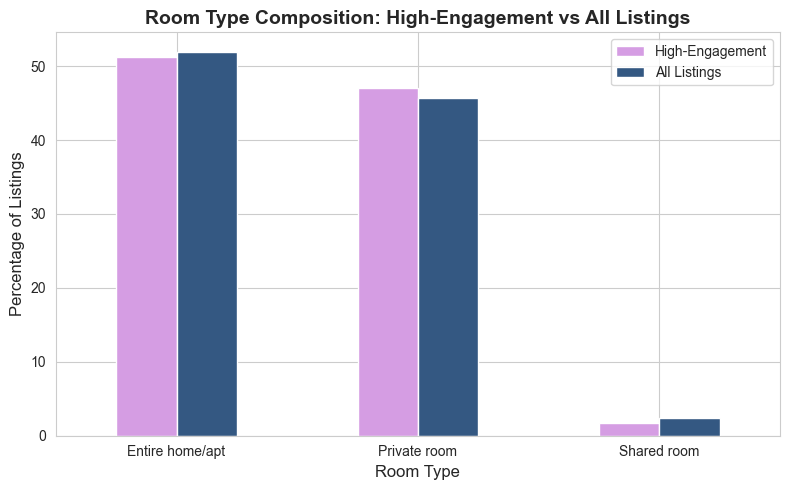

In [ ]:
# room type breakdown for high-engagement
print("\nRoom type distribution (high-engagement listings):")
high_eng_room = high_engagement["room_type"].value_counts()
print(high_eng_room)
print(f"\nVs all listings:")
all_room = df["room_type"].value_counts()
print(all_room)

print(f"\nHigh-engagement room type percentages:")
print((high_eng_room / len(high_engagement) * 100).round(2))
print(f"\nAll listings room type percentages:")
print((all_room / len(df) * 100).round(2))

# comparison bar chart
compare = pd.DataFrame({'High-Engagement': high_eng_room / len(high_engagement) * 100, 'All Listings': all_room / len(df) * 100}).fillna(0)
compare = compare.sort_index()
compare.plot(kind='bar', figsize=(8, 5), color=[primary, secondary])
plt.title('Room Type Composition: High-Engagement vs All Listings', fontsize=14, fontweight='bold')
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Percentage of Listings', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


Neighbourhood group distribution (high-engagement listings):
neighbourhood_group
Brooklyn         5242
Manhattan        4789
Queens           1718
Bronx             346
Staten Island     140
Name: count, dtype: int64

Percentages:
neighbourhood_group
Brooklyn         42.84
Manhattan        39.14
Queens           14.04
Bronx             2.83
Staten Island     1.14
Name: count, dtype: float64


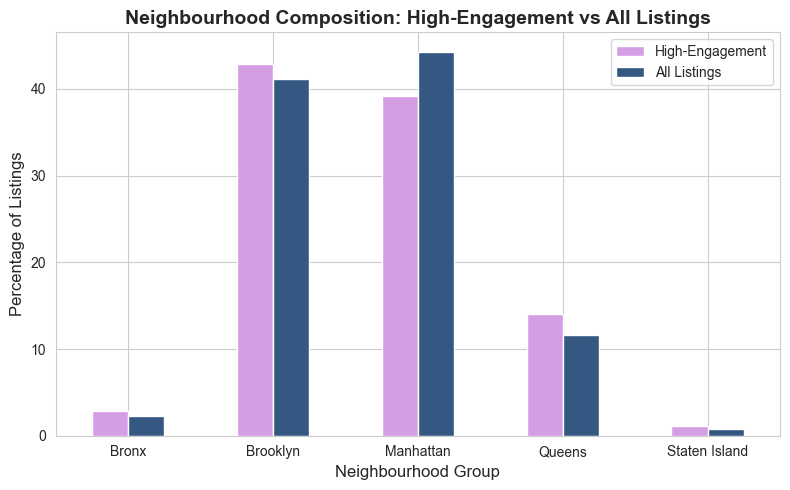

In [131]:
# neighbourhood group for high-engagement
print("\nNeighbourhood group distribution (high-engagement listings):")
high_eng_neigh = high_engagement["neighbourhood_group"].value_counts()
print(high_eng_neigh)
print(f"\nPercentages:")
print((high_eng_neigh / len(high_engagement) * 100).round(2))

# vs all
all_neigh = df["neighbourhood_group"].value_counts()
compare_neigh = pd.DataFrame({
    'High-Engagement': high_eng_neigh / len(high_engagement) * 100,
    'All Listings': all_neigh / len(df) * 100
}).fillna(0)
compare_neigh = compare_neigh.sort_index()
compare_neigh.plot(kind='bar', figsize=(8, 5), color=[primary, secondary])
plt.title('Neighbourhood Composition: High-Engagement vs All Listings', fontsize=14, fontweight='bold')
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Percentage of Listings', fontsize=12)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [132]:
# minimum nights for high-engagement
print(f"\nMinimum nights [high-engagement]:")
print(f"Mean: {high_engagement['minimum_nights'].mean():.0f} nights")
print(f"Median: {high_engagement['minimum_nights'].median():.0f} nights")
print(f"Percentage offering nightly rates: {(high_engagement['minimum_nights'] == 1).sum() / len(high_engagement) * 100:.1f}%")


Minimum nights [high-engagement]:
Mean: 4 nights
Median: 2 nights
Percentage offering nightly rates: 29.7%


### 11. The Top Performing Neighbourhoods

Which specific neighbourhoods attract the most guests? Are tourists clustering in predictable places or is there hidden value elsewhere?

In [147]:
# top neighbourhoods by review activity
top_neighbourhoods = df.groupby("neighbourhood").agg({"id": "count", "number_of_reviews": "mean", "price": "mean", "reviews_per_month": "mean", "neighbourhood_group": "first"}).round(2)

top_neighbourhoods.columns = ["Listing Count", "Avg Reviews", "Avg Price", "Reviews/Month", "Borough"]
top_neighbourhoods = top_neighbourhoods[top_neighbourhoods["Listing Count"] >= 50]  # filter for scale
top_neighbourhoods = top_neighbourhoods.sort_values("Reviews/Month", ascending=False)

print("Top neighbourhoods by review activity (50+ listings):")
top_neighbourhoods.head(10)

Top neighbourhoods by review activity (50+ listings):


,Listing Count,Avg Reviews,Avg Price,Reviews/Month,Borough
neighbourhood,,,,,
East Elmhurst,185,81.66,81.18,4.82,Queens
Springfield Gardens,85,69.09,94.24,4.46,Queens
Queens Village,60,35.78,83.93,3.22,Queens
Jamaica,231,42.90,95.77,3.15,Queens
Rosedale,59,28.36,76.69,2.68,Queens
Richmond Hill,94,34.36,87.12,2.65,Queens
Theater District,288,15.08,248.01,2.57,Manhattan
St. Albans,76,34.00,100.83,2.52,Queens
Mott Haven,60,42.37,88.92,2.43,Bronx


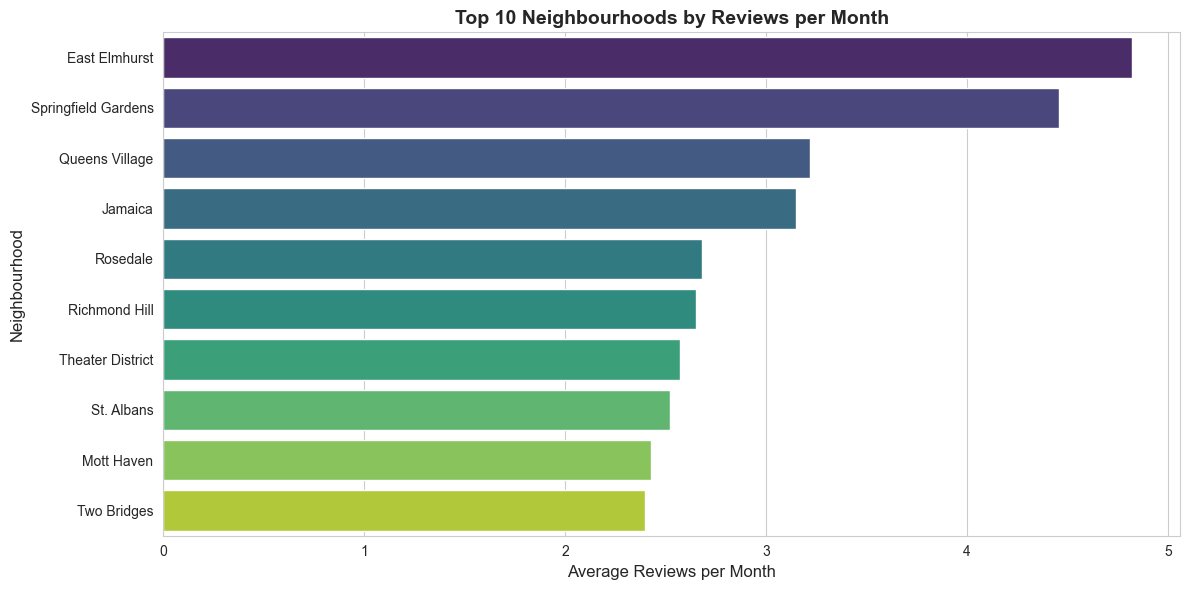

In [148]:
# bar chart
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_neighbourhoods.head(10), x='Reviews/Month', y=top_neighbourhoods.head(10).index, palette='viridis', ax=ax)
ax.set_title('Top 10 Neighbourhoods by Reviews per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Reviews per Month', fontsize=12)
ax.set_ylabel('Neighbourhood', fontsize=12)
plt.tight_layout()
plt.show()

In [151]:
# bottom performing neighbourhoods
print("\nBottom neighbourhoods by review activity (50+ listings):")
top_neighbourhoods.tail(10)


Bottom neighbourhoods by review activity (50+ listings):


,Listing Count,Avg Reviews,Avg Price,Reviews/Month,Borough
neighbourhood,,,,,
West Village,768,19.38,267.68,0.94,Manhattan
Midwood,109,15.18,80.34,0.93,Brooklyn
Greenwich Village,392,16.65,263.41,0.92,Manhattan
Greenpoint,1115,17.43,144.82,0.90,Brooklyn
Brooklyn Heights,154,16.59,209.06,0.89,Brooklyn
Fort Hamilton,55,13.55,93.82,0.84,Brooklyn
Tribeca,177,11.49,490.64,0.83,Manhattan
NoHo,78,12.74,295.72,0.80,Manhattan
Civic Center,52,12.25,191.94,0.78,Manhattan


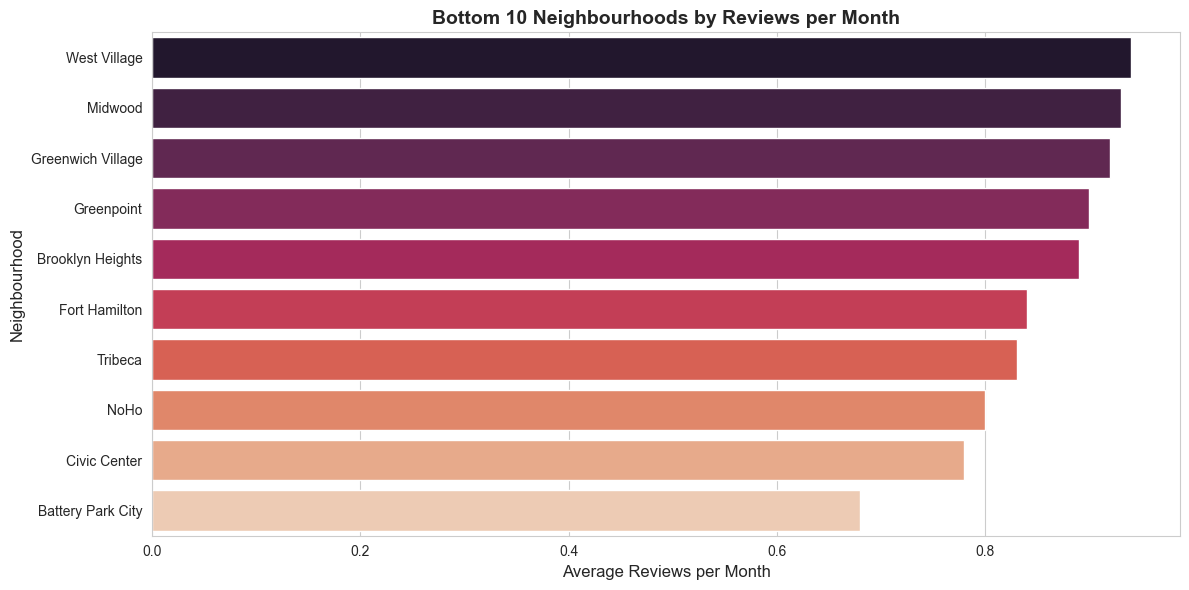

In [149]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_neighbourhoods.tail(10), x='Reviews/Month', y=top_neighbourhoods.tail(10).index, palette='rocket', ax=ax)
ax.set_title('Bottom 10 Neighbourhoods by Reviews per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Reviews per Month', fontsize=12)
ax.set_ylabel('Neighbourhood', fontsize=12)
plt.tight_layout()
plt.show()

### 12. Price Segmentation Analysis

How do different price tiers perform? Do luxury listings justify their prices with better engagement, or is there a price ceiling where bookings drop off?

In [153]:
# price segmentation
def segment_price(price):
    if price <= 100:
        return "Budget (≤$100)"
    elif price <= 200:
        return "Mid-range ($101-$200)"
    elif price <= 350:
        return "Premium ($201-$350)"
    elif price <= 500:
        return "Luxury ($351-$500)"
    else:
        return "Ultra-luxury ($500+)"

df["price_segment"] = df["price"].apply(segment_price)

# performance by price segment
price_performance = df.groupby("price_segment").agg({"id": "count", "price": ["mean", "median"], "number_of_reviews": ["mean", "median"], "reviews_per_month": "mean", "availability_365": "mean"}).round(2)

print("Performance by price segment:")
price_performance

Performance by price segment:


id    price        number_of_reviews         \
                       count     mean median              mean median   
price_segment                                                           
Budget (≤$100)         23928    67.86   68.0             24.39    6.0   
Luxury ($351-$500)      1412   428.24  409.0             14.22    3.0   
Mid-range ($101-$200)  16583   150.26  150.0             25.03    6.0   
Premium ($201-$350)     5928   265.48  250.0             18.21    4.0   
Ultra-luxury ($500+)    1044  1123.95  750.0             10.80    1.0   

                      reviews_per_month availability_365  
                                   mean             mean  
price_segment                                             
Budget (≤$100)                     1.46           104.96  
Luxury ($351-$500)                 1.37           161.44  
Mid-range ($101-$200)              1.28           105.98  
Premium ($201-$350)                1.32           139.07  
Ultra-luxury ($500+)               1.12           184.95

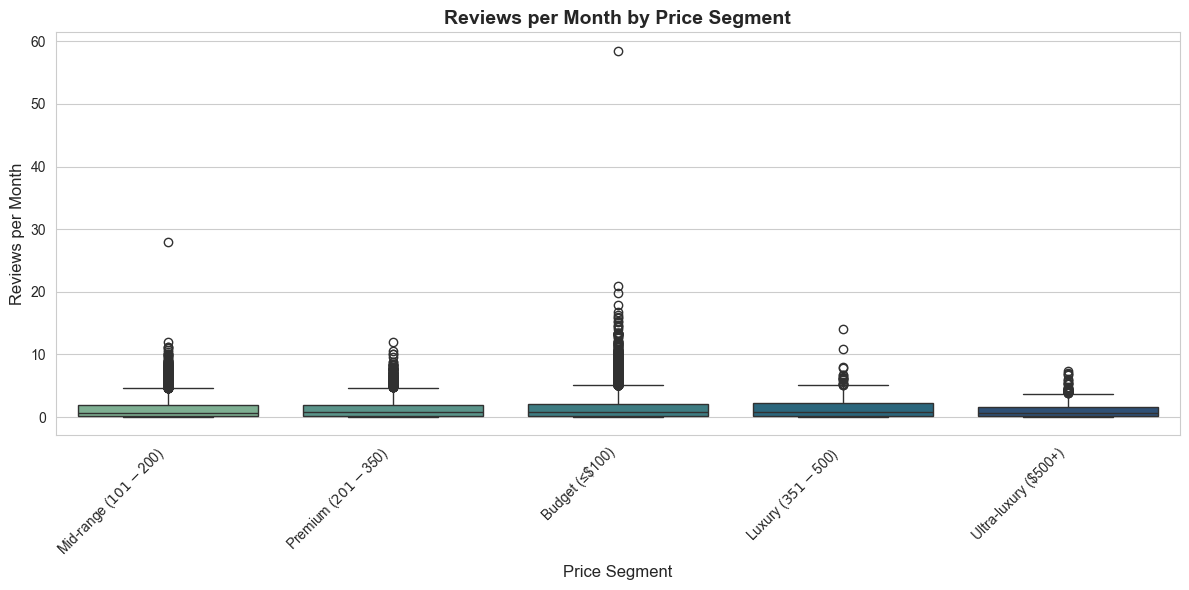

In [152]:
# boxplot of reviews per month by price segment
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[df['reviews_per_month'].notna()], x='price_segment', y='reviews_per_month', palette='crest', ax=ax)
ax.set_title('Reviews per Month by Price Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Segment', fontsize=12)
ax.set_ylabel('Reviews per Month', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [154]:
# room type distribution by price segment
price_room_crosstab = pd.crosstab(df["price_segment"], df["room_type"], normalize="index") * 100
print("\nRoom type distribution by price segment (%):")
price_room_crosstab.round(1)


Room type distribution by price segment (%):


room_type,Entire home/apt,Private room,Shared room
price_segment,,,
Budget (≤$100),19.1,76.6,4.3
Luxury ($351-$500),89.4,9.9,0.7
Mid-range ($101-$200),79.6,19.9,0.5
Premium ($201-$350),92.5,7.2,0.4
Ultra-luxury ($500+),85.5,13.7,0.8


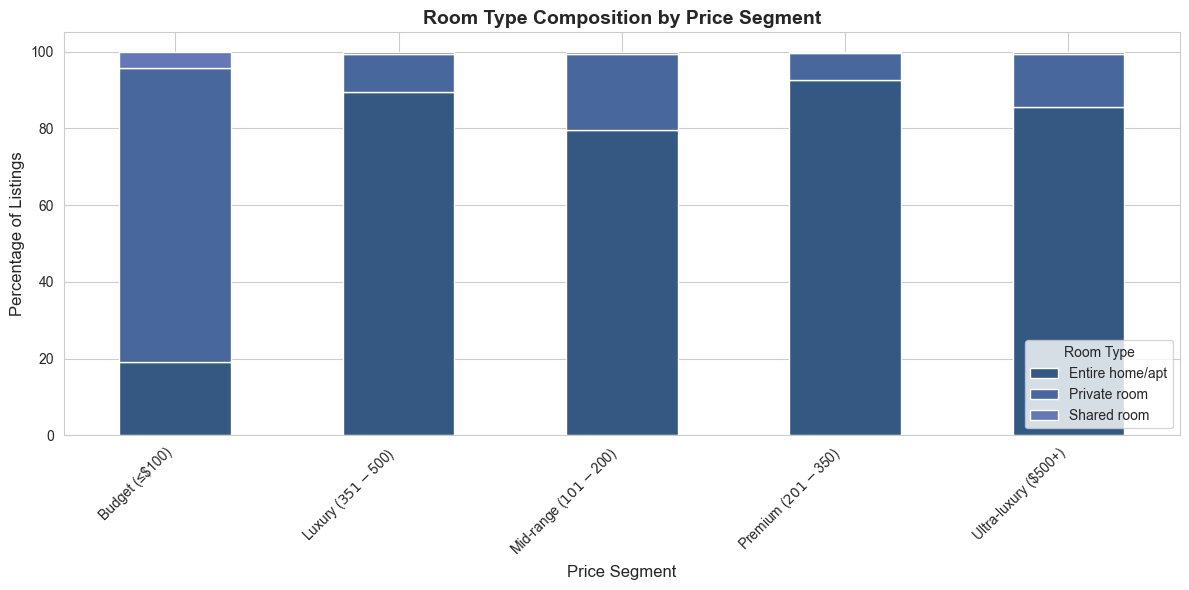

In [155]:
# stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
price_room_crosstab.plot(kind='bar', stacked=True, ax=ax, color=gradient[::-1])
ax.set_title('Room Type Composition by Price Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Segment', fontsize=12)
ax.set_ylabel('Percentage of Listings', fontsize=12)
ax.legend(title='Room Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 13. Machine Learning: Predicting Listing Price

Now that we understand the data, can we build a model that predicts a listing's price from its characteristics? I'll use a Random Forest regressor, which can capture non-linear relationships without much tuning. The goal isn't perfect prediction, but to identify which features most influence price and to see how well the model generalises.

In [137]:
# additional imports for ML
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import joblib

print("ML libraries imported.")

ML libraries imported.


In [138]:
# prepare features and target
ml_df = df.copy()

# Keep only relevant columns for modelling
features = ['neighbourhood_group', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month','calculated_host_listings_count', 'availability_365']
target = 'price'

# drop rows where reviews_per_month is NaN
ml_df = ml_df.dropna(subset=['reviews_per_month'])
print(f"Rows after dropping missing reviews_per_month: {len(ml_df)}")

x = ml_df[features]
y = ml_df[target]

# encode categorical variables
cat_cols = ['neighbourhood_group', 'room_type']
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])

# split into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training set: {len(x_train)} listings")
print(f"Test set: {len(x_test)} listings")

Rows after dropping missing reviews_per_month: 38843
Training set: 31074 listings
Test set: 7769 listings


In [157]:
# Train a Random Forest regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)

# Evaluate on test set
y_pred = rf.predict(x_test)

print(y_pred[:5])  # print first 5 predictions
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model performance on test set:")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.4f}")

# Cross-validation
cv_scores = cross_val_score(rf, x_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

[ 67.76326542 185.38825682 100.14638133 204.45971656  49.9000557 ]
Model performance on test set:
MAE: $58.47
RMSE: $165.65
R²: 0.0463

Cross-validation R² scores: [ 0.09859929  0.28110984  0.11932448  0.0710092  -0.17589164]
Mean CV R²: 0.0788


Feature importance:
                          Feature  Importance
2                  minimum_nights    0.224759
4               reviews_per_month    0.205906
6                availability_365    0.151267
1                       room_type    0.138476
0             neighbourhood_group    0.116041
5  calculated_host_listings_count    0.098950
3               number_of_reviews    0.064600


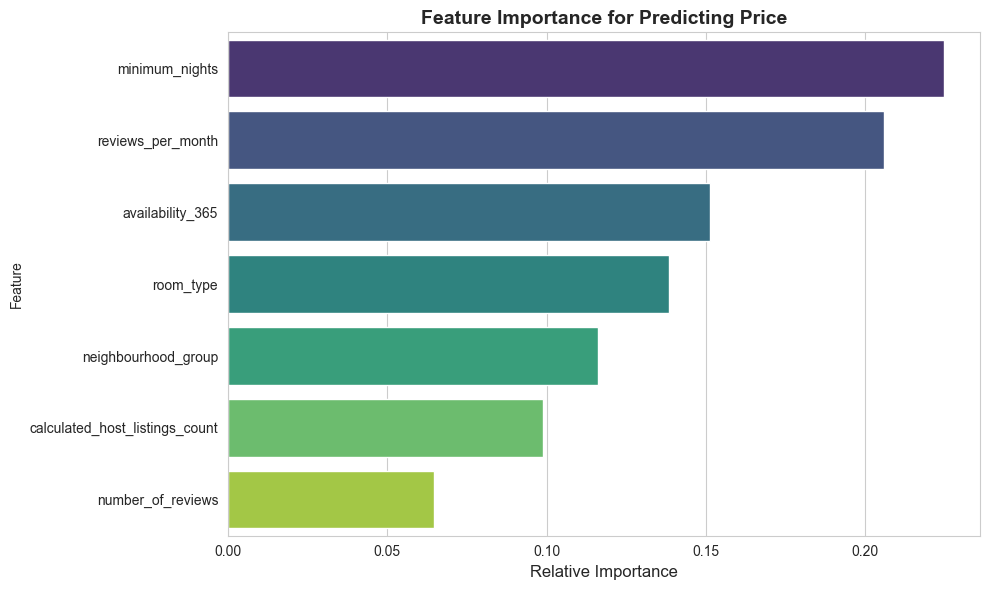

In [140]:
# Feature importance analysis
importances = rf.feature_importances_
feature_names = x.columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

print("Feature importance:")
print(imp_df)

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis', ax=ax)
ax.set_title('Feature Importance for Predicting Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Relative Importance', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

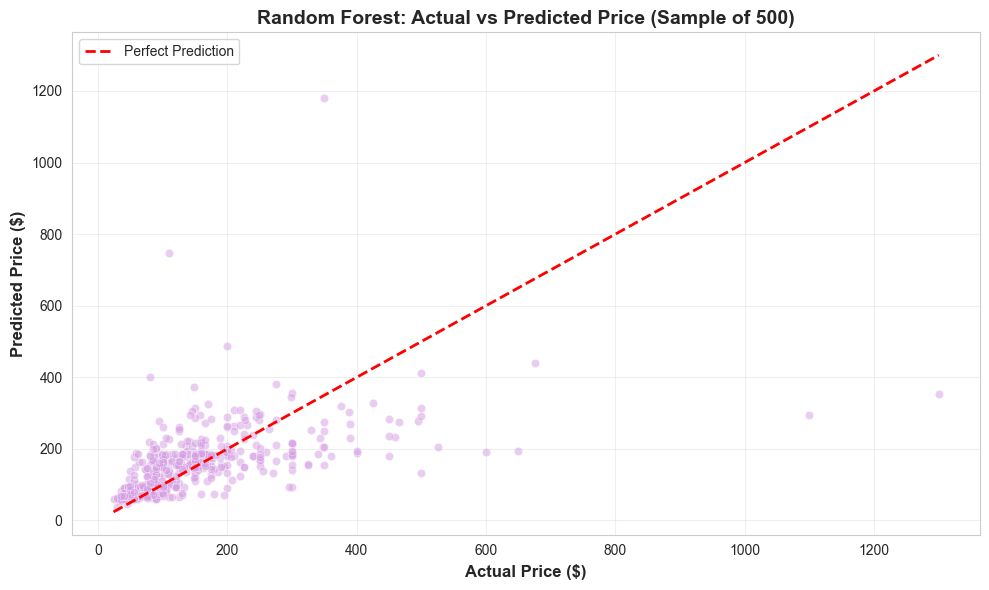

In [141]:
# Visualise actual vs predicted prices (sample for readability)
sample_size = 500  # limit to avoid overcrowding
sample_indices = np.random.choice(len(y_test), size=sample_size, replace=False)
y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = y_pred[sample_indices]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_sample, y_pred_sample, alpha=0.5, color=primary, edgecolors='white', linewidth=0.5)
ax.plot([y_test_sample.min(), y_test_sample.max()], [y_test_sample.min(), y_test_sample.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: Actual vs Predicted Price (Sample of 500)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

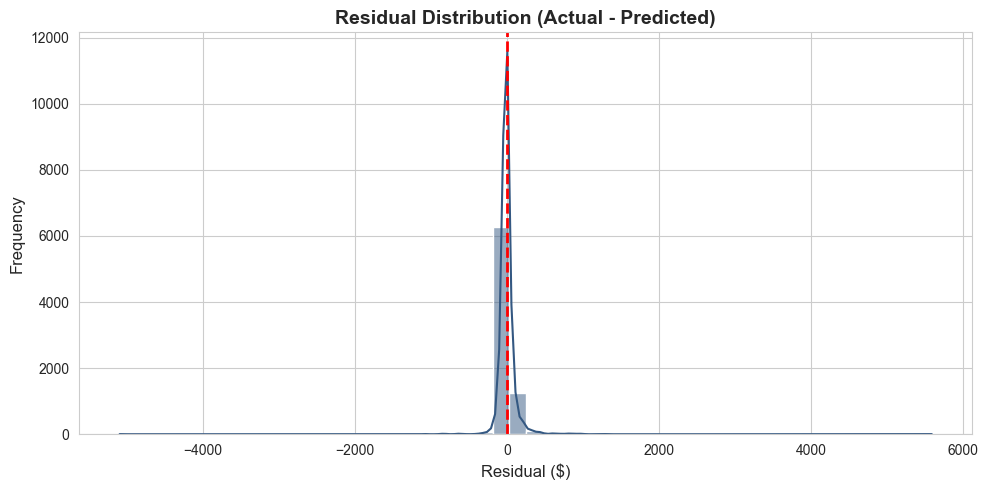

In [142]:
# Residual distribution
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color=secondary, ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_title('Residual Distribution (Actual - Predicted)', fontsize=14, fontweight='bold')
ax.set_xlabel('Residual ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [143]:
# Save the model
joblib.dump(rf, 'airbnb_price_predictor.pkl')
print("Model saved as 'airbnb_price_predictor.pkl'")

Model saved as 'airbnb_price_predictor.pkl'


### Summary: Key Findings and Patterns

After exploring the data, here's what stands out about NYC's Airbnb market.

In [144]:
# summary statistics
print("NY Airbnb Market Summary:")

print(f"\nDataset:")
print(f"Total listings: {len(df):,}")
print(f"Unique neighbourhoods: {df['neighbourhood'].nunique()}")
print(f"Borough distribution: {df['neighbourhood_group'].nunique()}")

print(f"\nPricing:")
print(f"Average nightly rate: ${df['price'].mean():.2f}")
print(f"Price range: ${df['price'].min():.0f} - ${df['price'].max():.0f}")
print(f"Most common segment: {df['price_segment'].mode()[0]}")

print(f"\nRoom types:")
print(f"Entire home/apt: {(df['room_type'] == 'Entire home/apt').sum():,} ({(df['room_type'] == 'Entire home/apt').sum()/len(df)*100:.1f}%)")
print(f"Private room: {(df['room_type'] == 'Private room').sum():,} ({(df['room_type'] == 'Private room').sum()/len(df)*100:.1f}%)")
print(f"Shared room: {(df['room_type'] == 'Shared room').sum():,} ({(df['room_type'] == 'Shared room').sum()/len(df)*100:.1f}%)")

print(f"\nEngagement:")
print(f"Listings with reviews: {(df['number_of_reviews'] > 0).sum():,} ({(df['number_of_reviews'] > 0).sum()/len(df)*100:.1f}%)")
print(f"Average reviews per listing: {df['number_of_reviews'].mean():.0f}")
print(f"Median reviews per listing: {df['number_of_reviews'].median():.0f}")
print(f"Active listings (reviewed in last 30 days): {(df['days_since_review'] <= 30).sum():,}")

print(f"\nHost Landscape:")
print(f"Average listings per host: {df['calculated_host_listings_count'].mean():.2f}")
print(f"Professional hosts (10+ listings): {(df['calculated_host_listings_count'] >= 10).sum():,}")
print(f"Individual hosts (single listing): {(df['calculated_host_listings_count'] == 1).sum():,}")

NY Airbnb Market Summary:

Dataset:
Total listings: 48,895
Unique neighbourhoods: 221
Borough distribution: 5

Pricing:
Average nightly rate: $152.72
Price range: $0 - $10000
Most common segment: Budget (≤$100)

Room types:
Entire home/apt: 25,409 (52.0%)
Private room: 22,326 (45.7%)
Shared room: 1,160 (2.4%)

Engagement:
Listings with reviews: 38,843 (79.4%)
Average reviews per listing: 23
Median reviews per listing: 5
Active listings (reviewed in last 30 days): 15,971

Host Landscape:
Average listings per host: 7.14
Professional hosts (10+ listings): 3,177
Individual hosts (single listing): 32,303


In [145]:
print("Insights:")

# insight 1: price-engagement relationship
low_price = df[df['price'] <= 150].copy()
high_price = df[df['price'] >= 300].copy()
low_rpm = low_price[low_price['reviews_per_month'].notna()]['reviews_per_month'].mean()
high_rpm = high_price[high_price['reviews_per_month'].notna()]['reviews_per_month'].mean()

print(f"\nPrice vs Engagement:")
print(f"Budget listings [<=$150]: {low_rpm:.2f} reviews/month")
print(f"Luxury listings [>=$300]: {high_rpm:.2f} reviews/month")
print(f"Budget listings get {(low_rpm/high_rpm):.1f}x more engagement")

# insight 2: room type impact
entire_rpm = df[df['room_type'] == 'Entire home/apt'][df['reviews_per_month'].notna()]['reviews_per_month'].mean()
private_rpm = df[df['room_type'] == 'Private room'][df['reviews_per_month'].notna()]['reviews_per_month'].mean()

print(f"\nRoom type:")
print(f"Entire home/apt: {entire_rpm:.2f} reviews/month")
print(f"Private room: {private_rpm:.2f} reviews/month")
print(f"Entire units get {(entire_rpm/private_rpm):.1f}x more bookings")

# insight 3: minimum stay impact
nightly = df[df['minimum_nights'] == 1][df['reviews_per_month'].notna()]['reviews_per_month'].mean()
long_stay = df[df['minimum_nights'] >= 30][df['reviews_per_month'].notna()]['reviews_per_month'].mean()

print(f"\nMinimum Stay Requirement:")
print(f"Nightly bookings: {nightly:.2f} reviews/month")
print(f"30+ day minimums: {long_stay:.2f} reviews/month")
print(f"Flexible policies get {(nightly/long_stay):.1f}x more engagement")

# insight 4: host portfolio impact
single = df[df['calculated_host_listings_count'] == 1][df['reviews_per_month'].notna()]['reviews_per_month'].mean()
multi = df[df['calculated_host_listings_count'] >= 10][df['reviews_per_month'].notna()]['reviews_per_month'].mean()

print(f"\nHost Portfolio Size:")
print(f"Individual hosts: {single:.2f} reviews/month")
print(f"Professional operators [10+ listings]: {multi:.2f} reviews/month")
print(f"Professional hosts get {(multi/single):.1f}x more engagement per listing")

Insights:

Price vs Engagement:
Budget listings [<=$150]: 1.41 reviews/month
Luxury listings [>=$300]: 1.33 reviews/month
Budget listings get 1.1x more engagement

Room type:
Entire home/apt: 1.31 reviews/month
Private room: 1.45 reviews/month
Entire units get 0.9x more bookings

Minimum Stay Requirement:
Nightly bookings: 2.06 reviews/month
30+ day minimums: 0.50 reviews/month
Flexible policies get 4.1x more engagement

Host Portfolio Size:
Individual hosts: 1.22 reviews/month
Professional operators [10+ listings]: 0.85 reviews/month
Professional hosts get 0.7x more engagement per listing


### Machine Learning Takeaway

The model achieved the following performance on the test data:
* Mean Absolute Error [MAE]: $58.47
* Root Mean Squared Error [RMSE]: $165.65
* R² Score: 0.046
* Mean Cross-Validation R²: 0.079

These results indicate that while the model was able to learn some patterns from the dataset, its predictive performance was limited. This suggests that Airbnb pricing is influenced by additional factors that were not included in the model, such as property amenities, exact location, seasonal demand, property size, and host reputation. 
Future improvements can include, but are not limited to aspects like include feature engineering, detailed listing information, other regression models to test the differences, and tuning hyperparameters to improve prediction accuracy.

### Conclusions and Observations

The NYC Airbnb market reveals a clear tension between maximising bookings and maximising revenue per booking. Cheaper listings drive volume but lower revenue. Entire homes outperform private rooms dramatically in engagement. Flexible booking policies (nightly rates) and professional host operations correlate with significantly higher engagement metrics.

The market is surprisingly active. Over 75% of listings have at least one review: but distributed unevenly. Manhattan dominates pricing and Brooklyn drives volume. The sweet spot appears to be mid-range entire apartments in accessible neighbourhoods with flexible policies and responsive hosts.

The machine learning model confirms that location and room type are the primary drivers of price, while engagement metrics are more closely tied to booking behaviour than to listing characteristics.